0.020435165016820505
Minimum X2: 57.22686366389826, Reduced X2: 0.2890245639590821
Parameters: A: -0.06993156303033599, B: 0.030029335825757925, C: 1.8999999493559294, l: 0.2801937451485573, δ: 0.10016814845204412
Minimum X2: 544.2488964704783, Reduced X2: 2.7487318003559507
Parameters: A: -0.06984470315529298, B: 0.030078475050948933, C: 1.8999996563737347, l: 0.2802909287757347, δ: 0.10224117378100911
Correlation Coefficient: 0.1393277524153158


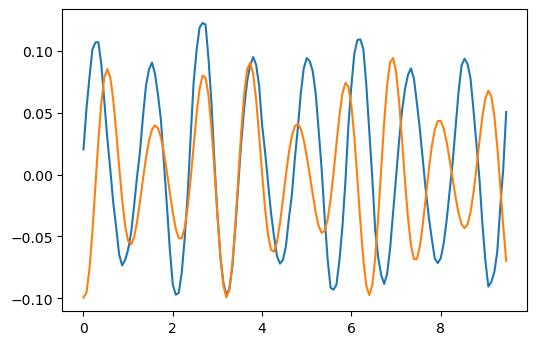

In [7]:
from numpy import array,append,ones_like,sqrt,linspace,arange,cos,sin,dot,arctan,e
import matplotlib.pyplot as plt

# Importing data
x = array([])
xerr = array([])
y = array([])
yerr = array([])
t = array([])

with open('Spring Pendulum Data Aggregate.csv') as file:
    lines = file.readlines()
    count = 1
    for line in lines:
        if count != 1:
            numbers = line.split(',')
            x = append(x, float(numbers[7]))
            xerr = append(xerr,float(numbers[8]))
            y = append(y, float(numbers[9]))
            yerr = append(yerr, float(numbers[10]))
            t = append(t,float(numbers[0]))
        count += 1
        
y1 = 0.483 - y
y1err = yerr**2

# Calculating phi and 
phi = arctan(x/y1)
print(phi[0])
phierr = sqrt((xerr**2 * (y1/(y1+x**2))**2) + (y1err**2 * (-x/x**2 + y1**2)**2))

# Creating a fit line with the parameters
def phifit(A,B,C,l,δ):
    g = 9.8
    fit = (A - B*cos(C*t))*cos(sqrt(g/l)*t - δ)
    return fit

def χ2(phi,phifit,phierr):
    return sum(((phi-phifit)**2)/abs(phifit))

def deriv(parameter,A,B,C,l,δ,Δ):
    f = 0.125
    if parameter == 'A':
        fit1 = phifit(A + (f*Δ),B,C,l,δ)
    elif parameter == 'B':
        fit1 = phifit(A,B + (f*Δ),C,l,δ)
    elif parameter == 'C':
        fit1 = phifit(A,B,C + (f*Δ),l,δ)
    elif parameter == 'l':
        fit1 = phifit(A,B,C,l + (f*Δ),δ)
    else:
        fit1 = phifit(A,B,C,l,δ + (f*Δ)) 
    fit2 = phifit(A,B,C,l,δ)
    deriv = (χ2(phi,fit1,phierr) - χ2(phi,fit2,phierr))/(f*Δ)
    return deriv
   
step = 0.0001
ΔA = 0.001
ΔB = 0.001
ΔC = 0.001
Δl = 0.00001    
Δδ = 0.001  

A = -0.07
B = 0.03
C = 1.9
l = 0.28
δ = 0.1

fit = phifit(A,B,C,l,δ)
oldgrad = 100000000000
diff = 1

count = 0
while diff > 1e-30:
    A += step*ΔA*deriv('A',A,B,C,l,δ,ΔA)
    B += step*ΔB*deriv('B',A,B,C,l,δ,ΔB)
    C += step*ΔC*deriv('C',A,B,C,l,δ,ΔC)
    l += step*Δl*deriv('l',A,B,C,l,δ,Δl)
    δ += step*Δδ*deriv('δ',A,B,C,l,δ,Δδ)
    fit = phifit(A,B,C,l,δ)
    newX2 = χ2(phi,fit,phierr)
    grad = sqrt((deriv('A',A,B,C,l,δ,ΔA))**2 + (deriv('B',A,B,C,l,δ,ΔB))**2 + (deriv('C',A,B,C,l,δ,ΔC))**2 + (deriv('l',A,B,C,l,δ,Δl))**2 + (deriv('δ',A,B,C,l,δ,Δδ))**2)
    diff = oldgrad - grad
    oldgrad = grad
    count += 1
    print(f'Minimum X2: {newX2}, Reduced X2: {newX2/(202-4)}')
    print(f'Parameters: A: {A}, B: {B}, C: {C}, l: {l}, δ: {δ}')

# Calculating numerator and denominator for r formula
num = dot(phi,fit)
den = sqrt(sum(phi**2)) * sqrt(sum(fit**2))

# Calculating r
r = num/den

print(f'Correlation Coefficient: {r}')


plt.figure(dpi=100)
plt.plot(t,phi)
# plt.plot(t,phi,'.')
plt.plot(t,fit)
plt.show()